Importar a imagem usando cv2

Criar matriz do kernel

Implementar funcao que multiplica cada componentes RGB dos pixels adjacentes pelo valor na matriz do kernel, soma tudo, faz a media e define o valor de RGB do pixel no centro do kernel.




## Imports

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#importar imagem

imagem = cv2.imread('dog.jpg')


In [5]:
# mostrar ela pra ver se esta tudo certo
cv2.imshow('janela', imagem) 
cv2.waitKey(0)
cv2.destroyAllWindows()


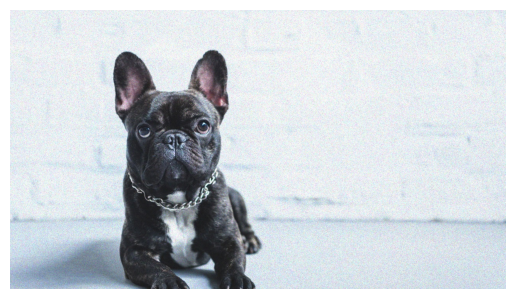

In [6]:
plt.axis('off')
plt.imshow(imagem[:, :, [2, 1, 0]])

In [7]:
imagem.shape

(720, 1280, 3)

In [8]:
# Preto e branco

# array da escala de cinza
escala_cinza = [0.114, 0.587, 0.299] 

preto_branco = np.dot(imagem, escala_cinza) # faz operacao de multiplicacao ponderada entre o array da imagem e o array da escala de cinza. 
# Multiplica cada componente BGR de cada pixel com os fatores de peso e soma tudo.
preto_branco = preto_branco.astype(np.uint8) # transforma o valor dos pixels pra 8bits (de novo) pro CV usar 




In [9]:
cv2.imshow('janela', preto_branco) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

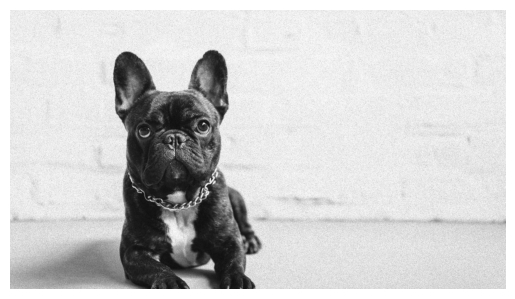

In [10]:
plt.axis('off')
plt.imshow(preto_branco, cmap='gray')

## Filtros 

In [11]:
preto_branco.shape

(720, 1280)

In [12]:
# Blur #Talvez usar
kernel1 = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)



In [13]:
# Gaussiano 
 
# definir kernel para usarmos na convolucao
kernel2 = np.array([
    [ 1,  4,  7,  4, 1],
    [ 4, 16, 26, 16, 4],
    [ 7, 26, 41, 26, 7],
    [ 4, 16, 26, 16, 4],
    [ 1,  4,  7,  4, 1]
], dtype=np.float32)

# formula basica da convolucao
# (I * K)[x, y] = Σ_i Σ_j I[x + i, y + j] · K[i, j]
# I = Imagem, K = kernel

# Rotacionar o kernel (nesse caso nao eh necessario pq a matriz gaussiana eh simetrica)
# kernel2_flip = np.flipud(np.fliplr(kernel2))

img_h, img_w = preto_branco.shape
ker_h, ker_w = kernel2.shape

# Definir o tamanho e tipo da saida
gauss = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1),dtype=np.uint8)

for i in range(gauss.shape[0]):
    for j in range(gauss.shape[1]):
        # definindo a regiao de interesse 
        regiao = preto_branco[i:i+ker_h, j:j+ker_w]
        # multiplica e soma todos os pixels dentro da regiao pelo kernel
        gauss[i, j] = (np.sum(regiao * kernel2)/273).astype(np.uint8)


In [14]:
cv2.imshow('janela', gauss) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

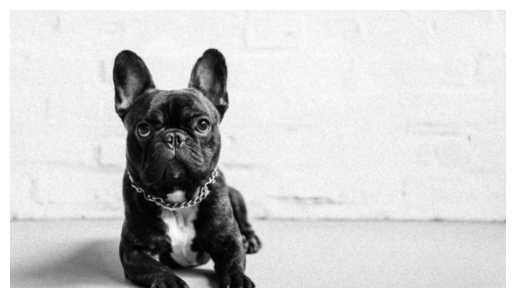

In [15]:
plt.axis('off')
plt.imshow(gauss, cmap='gray')

In [16]:
print(gauss)

[[236 235 235 ... 232 234 234]
 [238 236 235 ... 230 230 230]
 [235 234 233 ... 232 230 229]
 ...
 [189 191 191 ... 217 214 212]
 [186 186 189 ... 216 216 216]
 [187 187 190 ... 215 217 219]]


In [17]:
print(kernel2.sum())

273.0


In [18]:
# Sharpen (nitidez) # Talvez usar
kernel3 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

## Detecção de bordas

In [19]:
# Deteccao de borda

# Scharr X
kernel3 = np.array([
    [-3, 0, 3],
    [-10, 0, 10],
    [-3, 0, 3]
], dtype=np.float32)


img_h, img_w = gauss.shape
ker_h, ker_w = kernel3.shape

# Definir o tamanho e tipo da saida
scharrX = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))

for i in range(scharrX.shape[0]):
    for j in range(scharrX.shape[1]):
        # definindo a regiao de interesse 
        regiao = gauss[i:i+ker_h, j:j+ker_w]
        # multiplica e soma todos os pixels dentro da regiao pelo kernel. 
        scharrX[i, j] = (np.sum(regiao * kernel3))

# Normaliza 
scharrX = np.abs(scharrX)

# normaliza de novo para o maior valor 
scharrX = (scharrX/scharrX.max()*255)

# e converte para 8bits
scharrX_8bit = scharrX.astype(np.uint8)


In [20]:

cv2.imshow('janela', scharrX_8bit) 
cv2.waitKey(0)
cv2.destroyAllWindows()

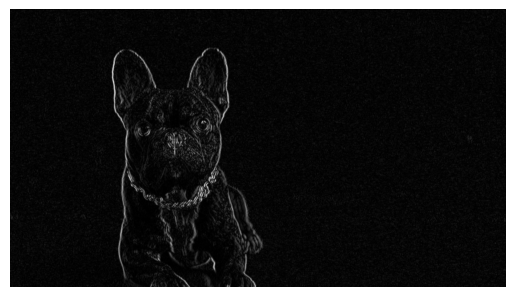

In [21]:
plt.axis('off')
plt.imshow(scharrX_8bit, cmap='gray')

In [22]:
#Scharr Y
kernel4 = np.array([
    [-3, -10, -3],
    [ 0,   0,  0],
    [ 3,  10,  3]
], dtype=np.float32)

img_h, img_w = gauss.shape
ker_h, ker_w = kernel4.shape

# Definir o tamanho e tipo da saida
scharrY = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))

for i in range(scharrY.shape[0]):
    for j in range(scharrY.shape[1]):
        # definindo a regiao de interesse 
        regiao = gauss[i:i+ker_h, j:j+ker_w]
        # multiplica e soma todos os pixels dentro da regiao pelo kernel. 
        scharrY[i, j] = (np.sum(regiao * kernel4))

#Normaliza pela soma absoluta do kernel
scharrY = np.abs(scharrY)

# normaliza de novo para o maior valor 
scharrY = (scharrY/scharrY.max()*255)

# e converte para 8bits
scharrY_8bit = scharrY.astype(np.uint8)

In [23]:
cv2.imshow('janela', scharrY_8bit) 
cv2.waitKey(0)
cv2.destroyAllWindows()

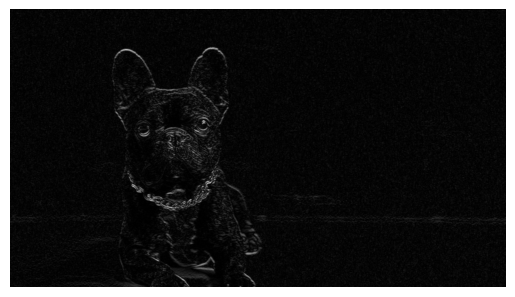

In [24]:
plt.axis('off')
plt.imshow(scharrY, cmap='gray')

In [25]:
# Junta os Scharrs

# calcula vetor resultante entre os dois scharrs
contorno = np.sqrt(scharrX**2+scharrY**2)

# normaliza
contorno = (contorno/contorno.max()*255).astype(np.uint8)


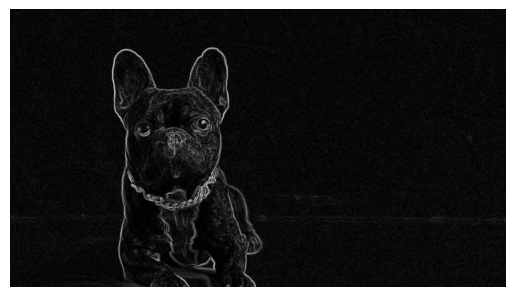

In [26]:
plt.axis('off')
plt.imshow(contorno, cmap='gray')

In [27]:
cv2.imshow('janela', contorno) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

# Remover ruido


## Thresholding 

In [42]:
threshold = 60
binario = np.where(contorno < threshold, 0, 1)

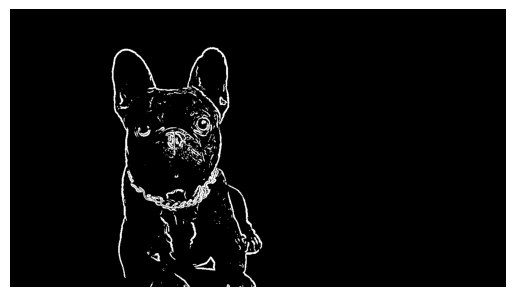

In [43]:
plt.axis('off')
plt.imshow(binario, cmap='gray')

## Erosão

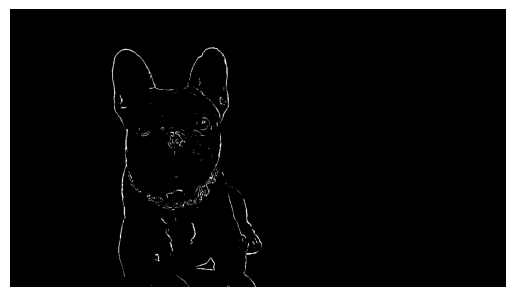

In [54]:
# Erosao
entrada = binario

aresta_k = 3
kernel5 = (np.ones((aresta_k, aresta_k))).astype(np.float32)

img_h, img_w = entrada.shape
ker_h, ker_w = kernel5.shape

pad_width = 1

iteracao = 2
# Definir o tamanho e tipo da saida
erosao = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))
#erosao = np.pad(contorno, pad_width, mode='edge')

for i in range(erosao.shape[0]):
    for j in range(erosao.shape[1]):
        # definindo a regiao de interesse
        regiao = entrada[i:i+ker_h, j:j+ker_w]
        # transforma o valor do pixel no menor valor dentro do kernel 
        erosao[i, j] = regiao.min()

# e converte para 8bits
erosao = erosao.astype(np.uint8)

plt.axis('off')
plt.imshow(erosao, cmap='gray')

In [32]:
cv2.imshow('janela', erosao) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

## Dilatação

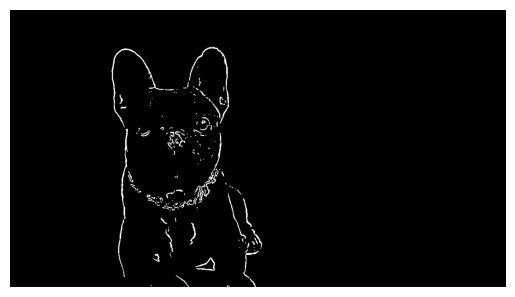

In [55]:
# dilatacao

kernel6 = (np.ones((2, 2))).astype(np.float32)
iteracao = 2

img_h, img_w = erosao.shape
ker_h, ker_w = kernel6.shape

# Definir o tamanho e tipo da saida
dilatacao = np.zeros((img_h - ker_h + 1, img_w - ker_w + 1))

for i in range(dilatacao.shape[0]):
    for j in range(dilatacao.shape[1]):
        # definindo a regiao de interesse 
        regiao = erosao[i:i+ker_h, j:j+ker_w]
        # transforma o valor do pixel no maior valor dentro do kernel 
        dilatacao[i, j] = regiao.max()


# e converte para 8bits
dilatacao = dilatacao.astype(np.uint8)

plt.axis('off')
plt.imshow(dilatacao, cmap='gray')

In [35]:
cv2.imshow('janela', dilatacao) # mostrar a imagem em escala de cinza
cv2.waitKey(0)
cv2.destroyAllWindows()

# Exportar os pontos de contorno